In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
DATAFRAME = '../data/bcw_data.csv'

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


# Contexte médical : Cancer du sein

Le cancer du sein correspond à une prolifération anormale de cellules mammaires.

Cette prolifération peut entraîner :

- Formation d'une masse palpable
- Modification de la forme du sein
- Irrégularité du contour tumoral
- Asymétrie tissulaire
- Croissance désorganisée

Ces manifestations macroscopiques sont la conséquence de modifications cellulaires microscopiques.

# Description du dataset

Ce dataset ne contient pas les symptômes cliniques visibles. Une ligne est une observation clinique.

Il contient des mesures morphologiques des noyaux cellulaires extraites d’images médicales.

Chaque caractéristique est mesurée selon trois dimensions :

- mean : moyenne
- se : variabilité (erreur standard)
- worst : valeur maximale observée

Les variables peuvent être regroupées en trois catégories :

## 1. Taille
- radius
- perimeter
- area

## 2. Forme et irrégularité
- smoothness
- compactness
- concavity
- concave points

## 3. Complexité et organisation
- symmetry
- fractal_dimension

# Lien théorique entre biologie et variables

Les symptômes cliniques observés sont la conséquence de phénomènes biologiques :

- Une masse volumineuse peut correspondre à une augmentation de la taille cellulaire.
- Une forme irrégulière peut correspondre à une croissance désorganisée.
- Une asymétrie peut refléter une perte de contrôle cellulaire.

Ces phénomènes pourraient se traduire dans le dataset par :

- Des valeurs élevées de radius, area, perimeter
- Des valeurs élevées de concavity et concave points
- Une variation dans symmetry et fractal_dimension

Ces éléments constituent des hypothèses à vérifier par l’analyse exploratoire.

# Analyse Dataset

In [3]:
df = pd.read_csv(DATAFRAME)

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
col = df.columns
print(col)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


In [6]:
df['Unnamed: 32'].value_counts()

Series([], Name: count, dtype: int64)

Colonnes non essentiel 

Nous avons une colonne ID et une colonne Unnamed: 32. Ces deux attribut ne sont pas essentiel à notre modèle. Ansi nous allons les supprimer

In [7]:
df = df.drop(columns=['Unnamed: 32', 'id'])

In [8]:
print("Shape:", df.shape)
print("Null total:", df.isna().sum())
print("Doublons:", df.duplicated().sum())


Shape: (569, 31)
Null total: diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Doublons: 0


# Hypothèses

H1 : Les tumeurs malignes présentent des noyaux de plus grande taille.

H2 : Les tumeurs malignes présentent des contours plus irréguliers.

H3 : Les tumeurs malignes présentent une organisation plus complexe ou moins symétrique.

Ces hypothèses seront testées à l’aide d’analyses statistiques et de visualisations.

# Analyse target

In [9]:
y = df['diagnosis']
list = ['diagnosis']
x = df.drop(list,axis = 1 )
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Number of Benign:  357
Number of Malignant :  212


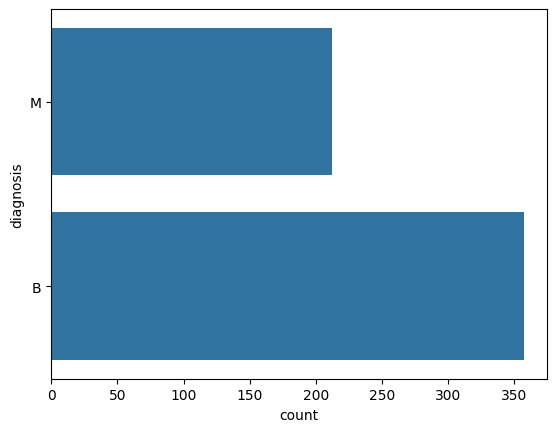

In [10]:
ax = sns.countplot(y,label="Count")
B, M = y.value_counts()
print('Number of Benign: ',B)
print('Number of Malignant : ',M)

# Analyse exploratoire

Nous allons :

1. Comparer les moyennes des variables entre les classes bénigne et maligne.
2. Visualiser les distributions via des boxplots.
3. Examiner les corrélations.
4. Identifier les variables les plus discriminantes.

In [11]:
x.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Visualisation des variables

Analysons maintenant les distributions et relations entre variables pour mieux comprendre le jeu de données avant la PCA.

In [14]:
import numpy as np

# Configuration générale des graphiques
plt.style.use('default')
sns.set_palette("husl")
fig_size = (15, 10)

## 1. Matrice de corrélation

Examinons les corrélations entre toutes les variables pour identifier les redondances avant la PCA.

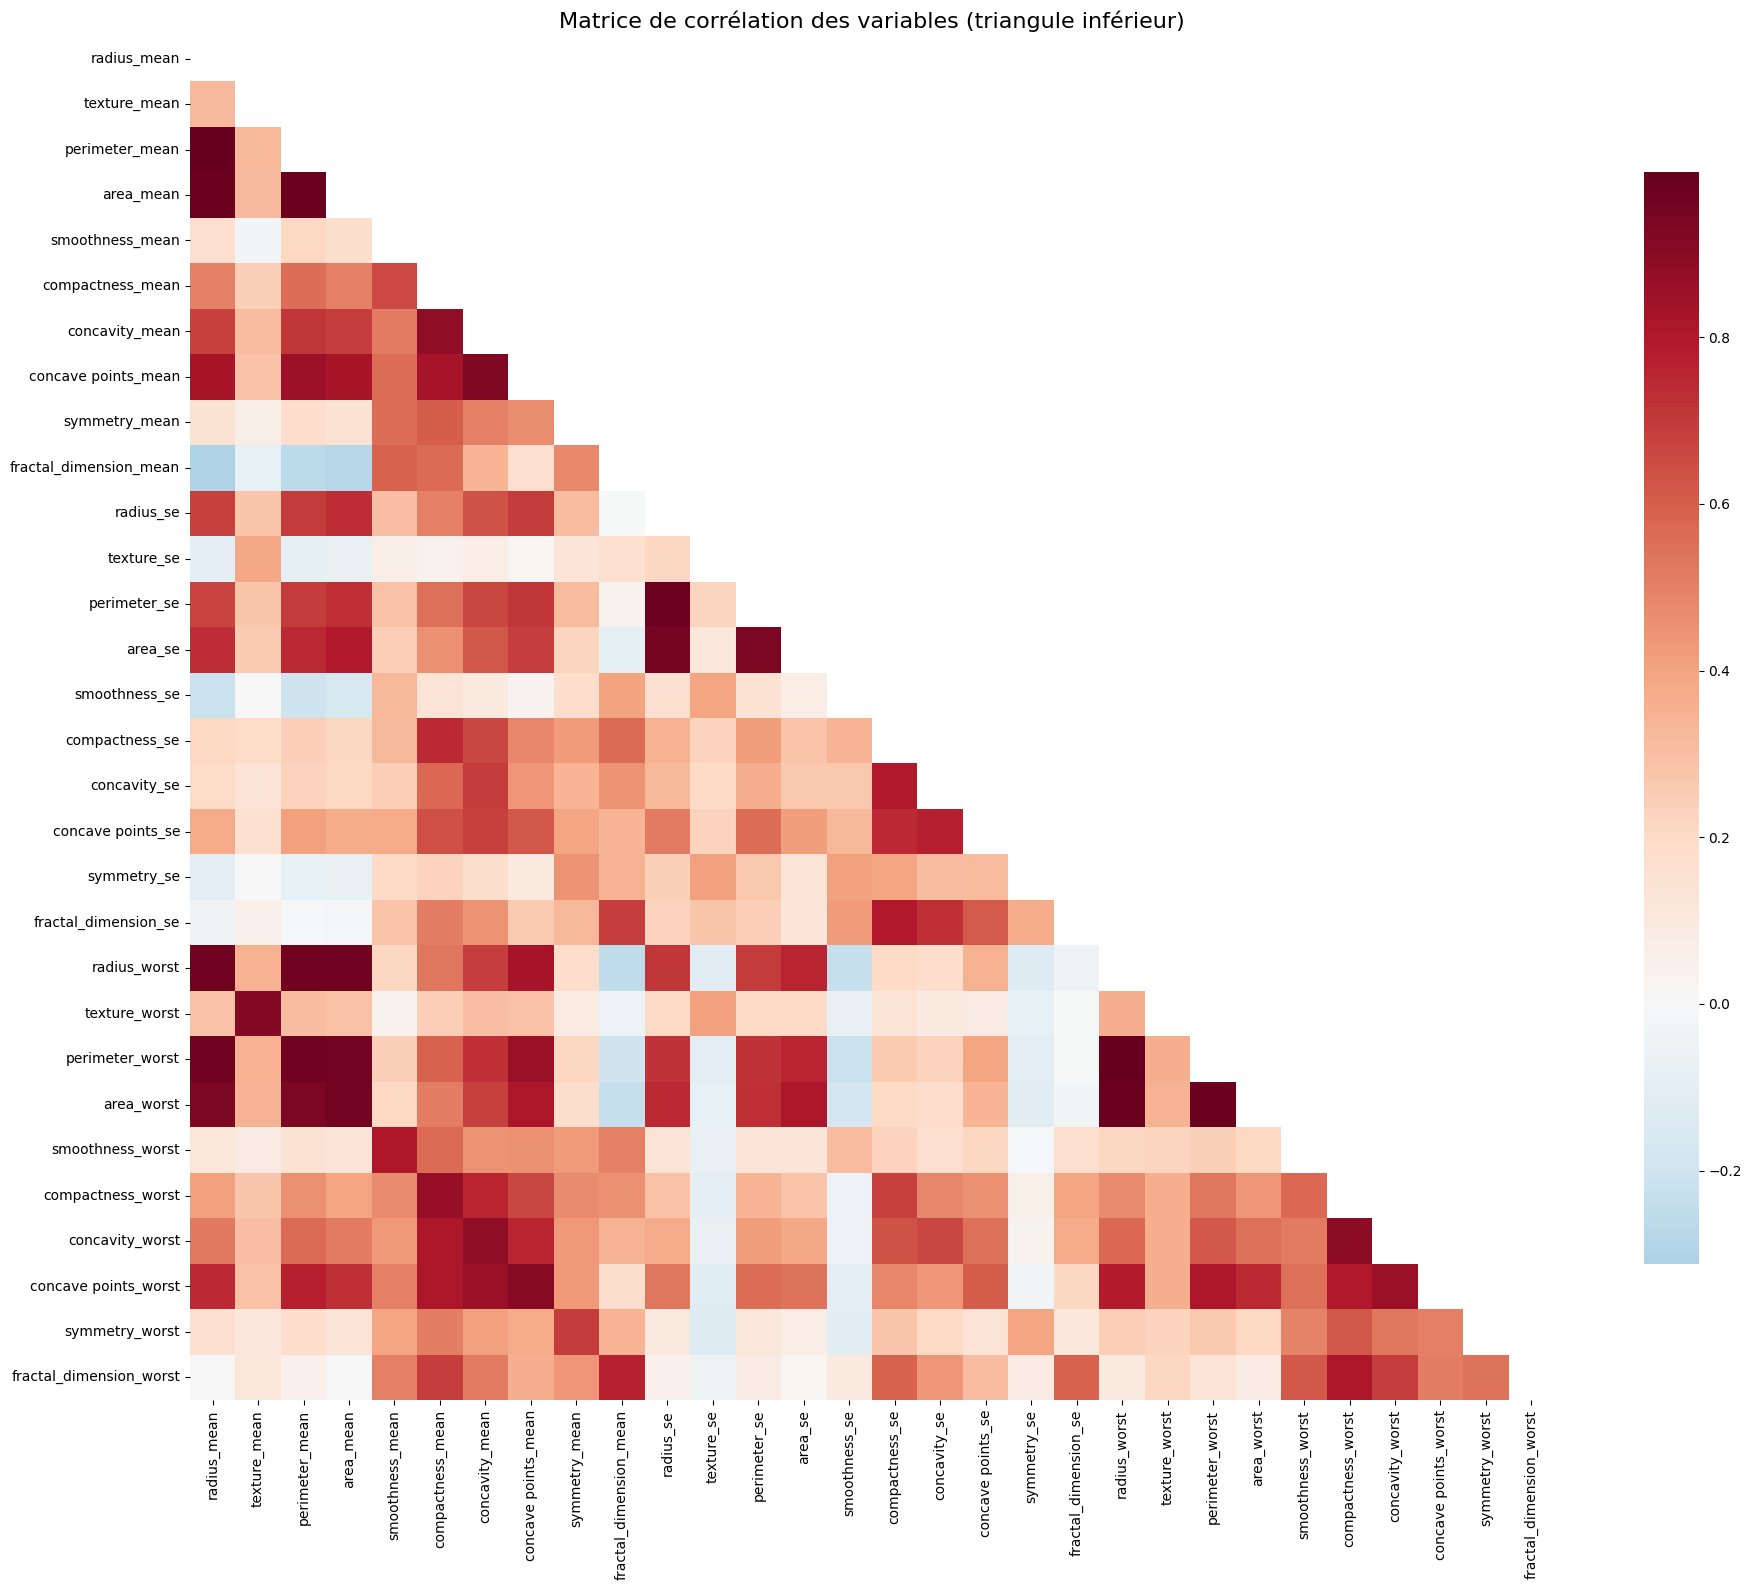

Paires de variables avec corrélation > 0.8 (en valeur absolue):
radius_mean <-> perimeter_mean: 0.998
radius_worst <-> perimeter_worst: 0.994
radius_mean <-> area_mean: 0.987
perimeter_mean <-> area_mean: 0.987
radius_worst <-> area_worst: 0.984
perimeter_worst <-> area_worst: 0.978
radius_se <-> perimeter_se: 0.973
perimeter_mean <-> perimeter_worst: 0.970
radius_mean <-> radius_worst: 0.970
perimeter_mean <-> radius_worst: 0.969
radius_mean <-> perimeter_worst: 0.965
area_mean <-> radius_worst: 0.963
area_mean <-> area_worst: 0.959
area_mean <-> perimeter_worst: 0.959
radius_se <-> area_se: 0.952
perimeter_mean <-> area_worst: 0.942
radius_mean <-> area_worst: 0.941
perimeter_se <-> area_se: 0.938
concavity_mean <-> concave points_mean: 0.921
texture_mean <-> texture_worst: 0.912
concave points_mean <-> concave points_worst: 0.910
compactness_worst <-> concavity_worst: 0.892
concavity_mean <-> concavity_worst: 0.884
compactness_mean <-> concavity_mean: 0.883
compactness_mean <-> comp

In [15]:
# Matrice de corrélation
plt.figure(figsize=(20, 16))
correlation_matrix = x.corr()

# Heatmap avec annotations pour les corrélations importantes
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', 
            center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})

plt.title('Matrice de corrélation des variables (triangule inférieur)', fontsize=16)
plt.tight_layout()
plt.show()

# Identification des corrélations les plus fortes
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:  # Seuil pour les corrélations fortes
            corr_pairs.append((correlation_matrix.columns[i], 
                             correlation_matrix.columns[j], 
                             corr_val))

print(f"Paires de variables avec corrélation > 0.8 (en valeur absolue):")
for var1, var2, corr in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{var1} <-> {var2}: {corr:.3f}")

## 2. Distribution des variables par diagnostic

Testons nos hypothèses en comparant les distributions des variables entre tumeurs bénignes et malignes.

In [16]:
# Créer un dataframe avec diagnosis pour les analyses comparatives
df_viz = x.copy()
df_viz['diagnosis'] = y

# Variables de taille (H1)
size_vars = [col for col in x.columns if 'radius' in col or 'area' in col or 'perimeter' in col]

# Variables de forme et irrégularité (H2) 
shape_vars = [col for col in x.columns if any(term in col for term in ['smoothness', 'compactness', 'concavity', 'concave points'])]

# Variables de complexité et organisation (H3)
complexity_vars = [col for col in x.columns if 'symmetry' in col or 'fractal_dimension' in col]

print("Variables de TAILLE (H1):", len(size_vars))
print("Variables de FORME/IRRÉGULARITÉ (H2):", len(shape_vars))  
print("Variables de COMPLEXITÉ/ORGANISATION (H3):", len(complexity_vars))

Variables de TAILLE (H1): 9
Variables de FORME/IRRÉGULARITÉ (H2): 12
Variables de COMPLEXITÉ/ORGANISATION (H3): 6


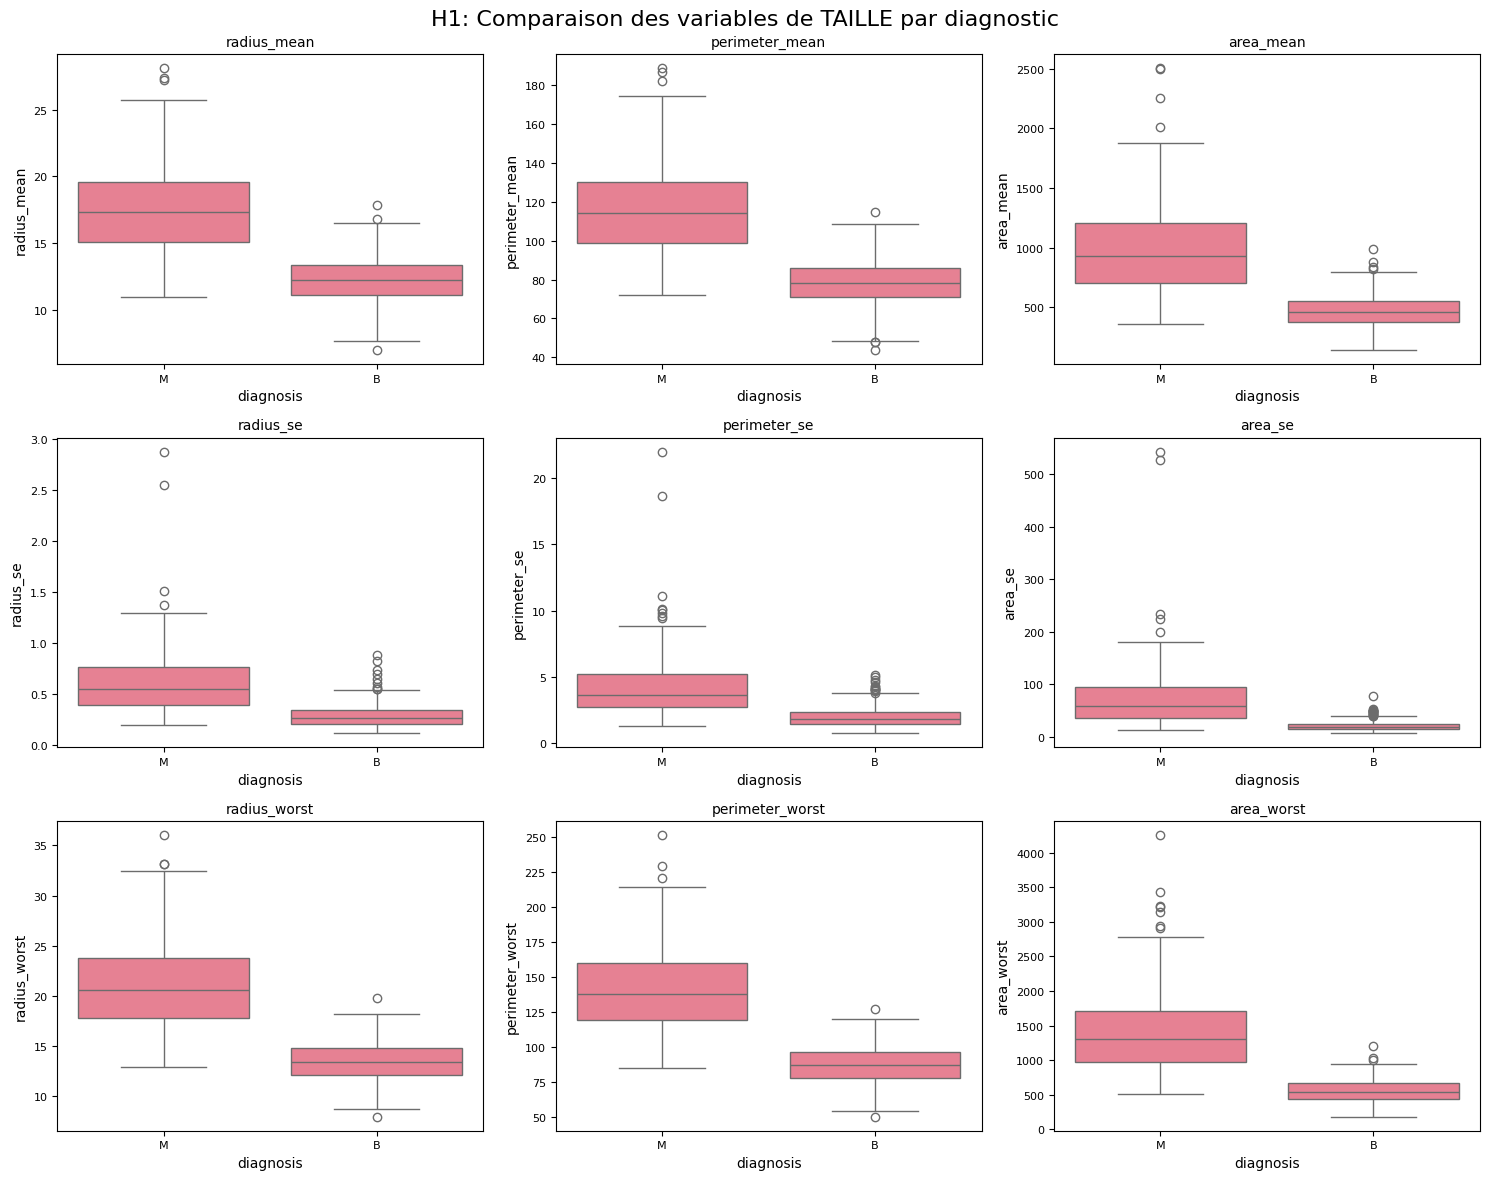

In [17]:
# Fonction pour créer des boxplots comparatifs
def plot_variable_comparison(variables, title, rows=3, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()
    
    for i, var in enumerate(variables[:rows*cols]):
        sns.boxplot(data=df_viz, x='diagnosis', y=var, ax=axes[i])
        axes[i].set_title(var, fontsize=10)
        axes[i].tick_params(axis='x', labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
    
    # Supprimer les axes vides
    for i in range(len(variables), rows*cols):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# H1: Variables de taille
plot_variable_comparison(size_vars, "H1: Comparaison des variables de TAILLE par diagnostic", 3, 3)

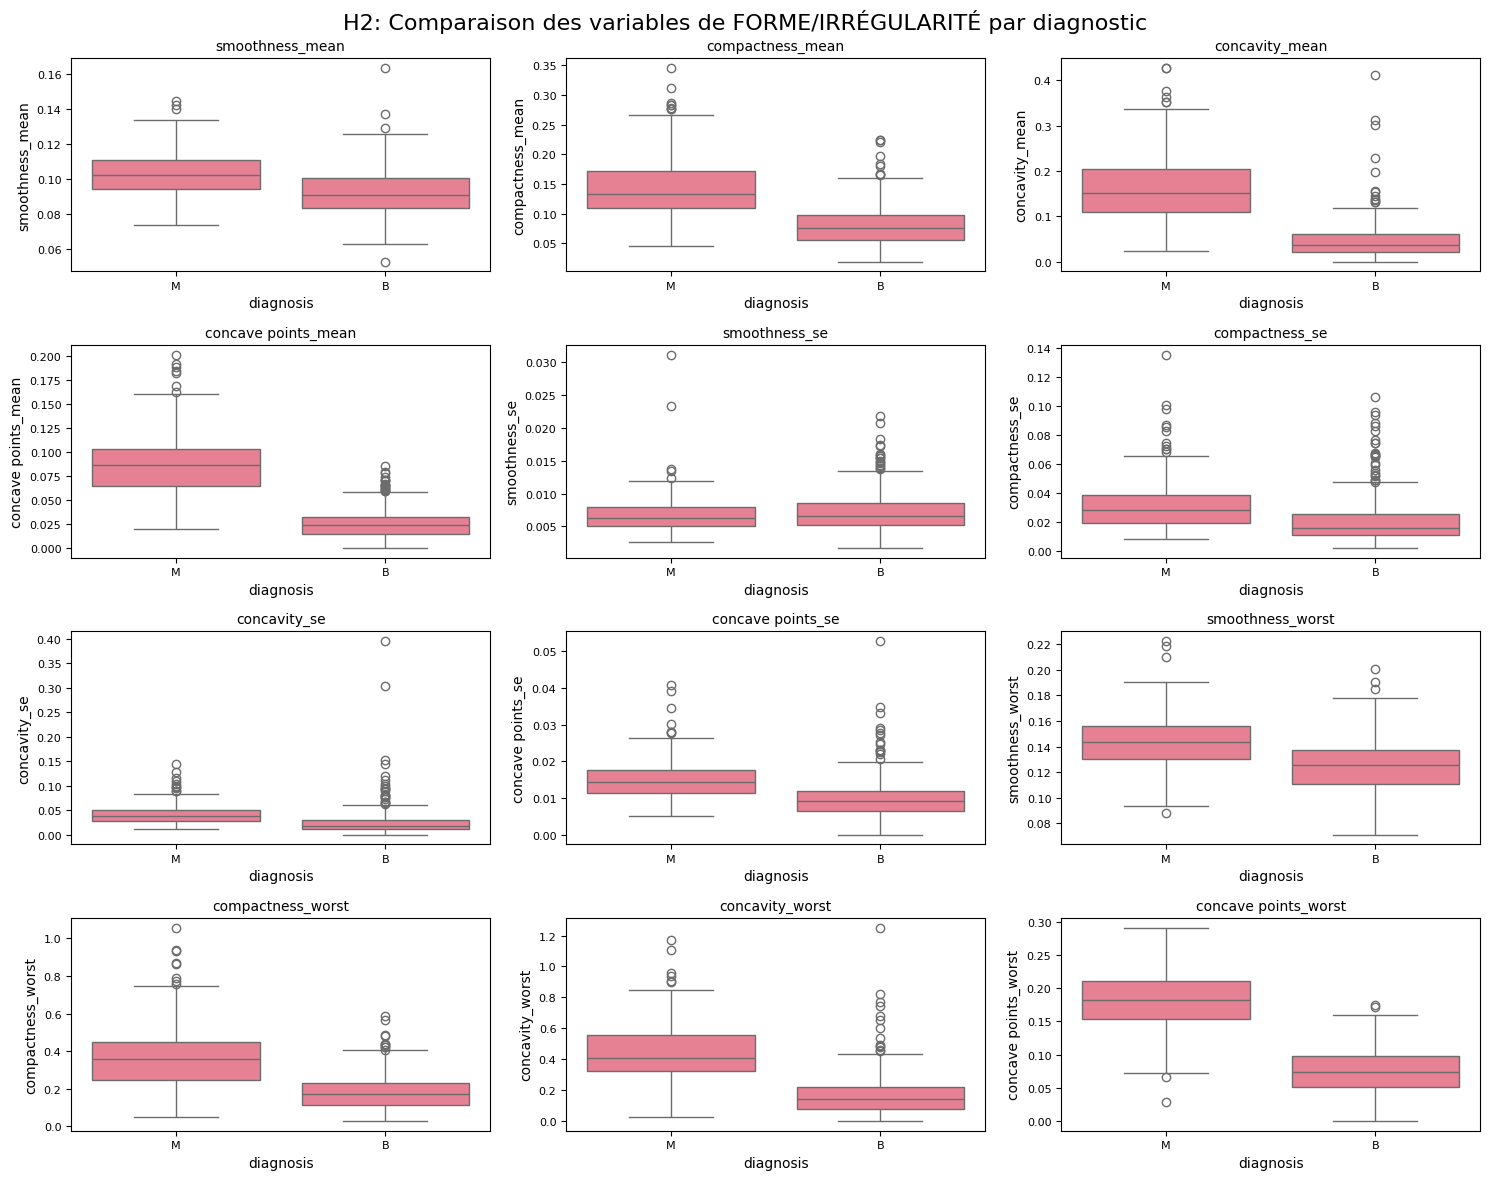

In [18]:
# H2: Variables de forme et irrégularité
plot_variable_comparison(shape_vars, "H2: Comparaison des variables de FORME/IRRÉGULARITÉ par diagnostic", 4, 3)

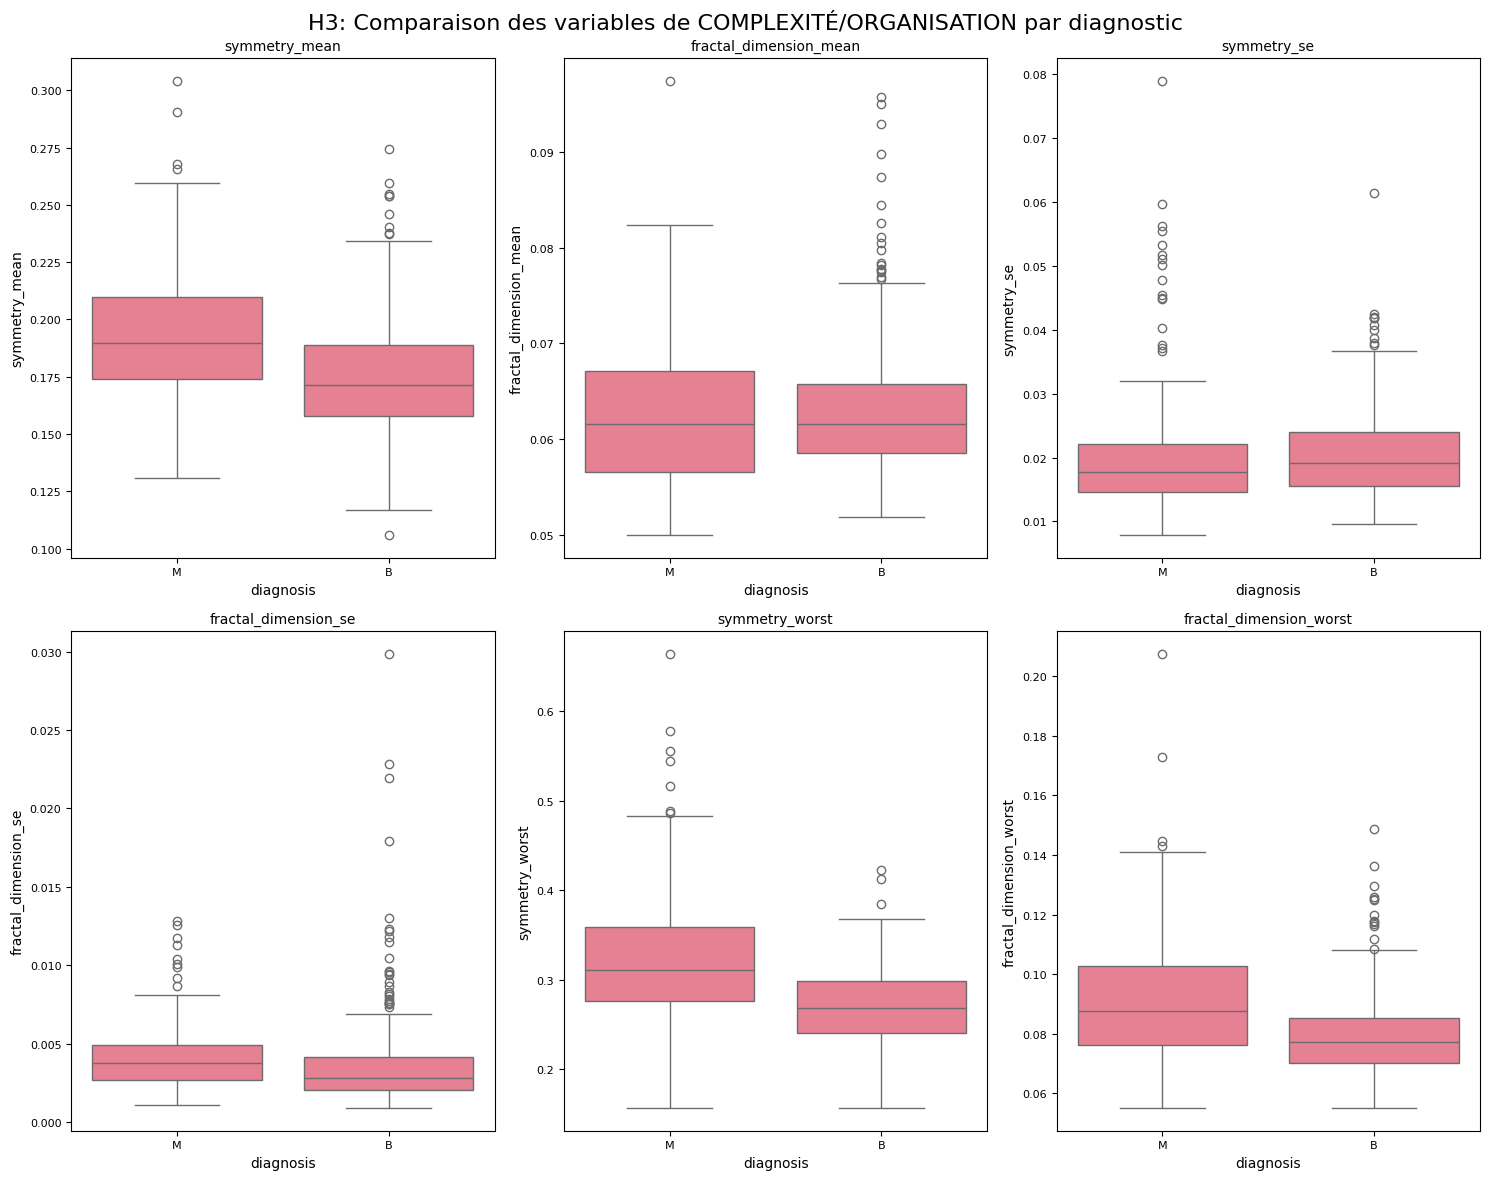

In [19]:
# H3: Variables de complexité et organisation  
plot_variable_comparison(complexity_vars, "H3: Comparaison des variables de COMPLEXITÉ/ORGANISATION par diagnostic", 2, 3)

## 3. Analyse des groupes de mesures (mean, se, worst)

Examinons comment se comportent les différents types de mesures pour identifier les patterns.

Variables moyennes (_mean): 10
Variables variabilité (_se): 10
Variables maximales (_worst): 10


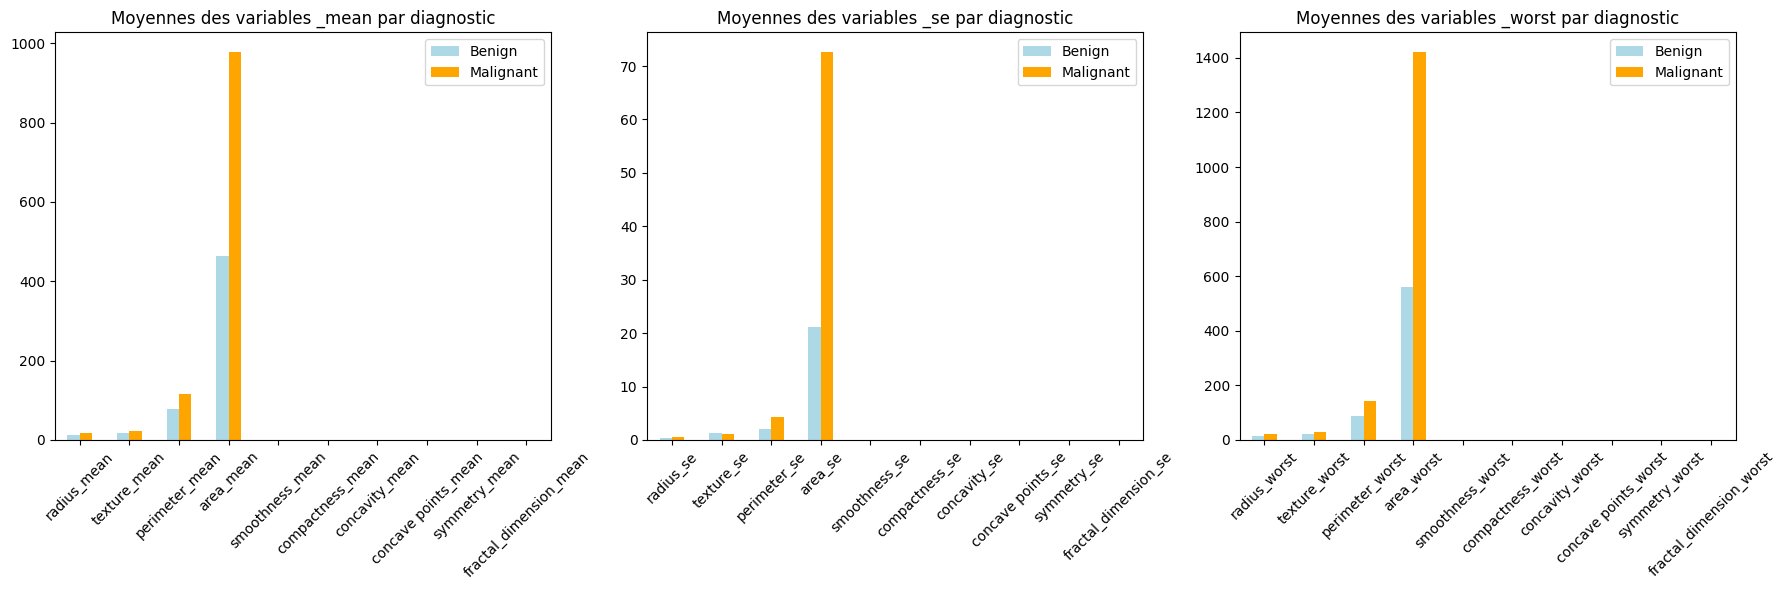

In [20]:
# Séparer les variables par type de mesure
mean_vars = [col for col in x.columns if '_mean' in col]
se_vars = [col for col in x.columns if '_se' in col]  
worst_vars = [col for col in x.columns if '_worst' in col]

print(f"Variables moyennes (_mean): {len(mean_vars)}")
print(f"Variables variabilité (_se): {len(se_vars)}")
print(f"Variables maximales (_worst): {len(worst_vars)}")

# Comparaison des moyennes par diagnostic pour chaque groupe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Moyennes pour chaque type de mesure
mean_comparison = df_viz.groupby('diagnosis')[mean_vars].mean()
se_comparison = df_viz.groupby('diagnosis')[se_vars].mean()
worst_comparison = df_viz.groupby('diagnosis')[worst_vars].mean()

# Plot 1: Variables moyennes
mean_comparison.T.plot(kind='bar', ax=axes[0], color=['lightblue', 'orange'])
axes[0].set_title('Moyennes des variables _mean par diagnostic')
axes[0].legend(['Benign', 'Malignant'])
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Variables de variabilité  
se_comparison.T.plot(kind='bar', ax=axes[1], color=['lightblue', 'orange'])
axes[1].set_title('Moyennes des variables _se par diagnostic')
axes[1].legend(['Benign', 'Malignant'])
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Variables maximales
worst_comparison.T.plot(kind='bar', ax=axes[2], color=['lightblue', 'orange'])
axes[2].set_title('Moyennes des variables _worst par diagnostic')
axes[2].legend(['Benign', 'Malignant'])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Variables les plus discriminantes

Identifions les variables qui séparent le mieux les deux classes avant la PCA.

Top 15 des variables les plus discriminantes:
Variable				Score	Différence (M-B)
------------------------------------------------------------
concave points_worst          	1.640	   0.108
perimeter_worst               	1.618	  54.364
concave points_mean           	1.605	   0.062
radius_worst                  	1.605	   7.755
perimeter_mean                	1.535	  37.290
area_worst                    	1.516	 863.387
radius_mean                   	1.509	   5.316
area_mean                     	1.465	 515.586
concavity_mean                	1.439	   0.115
concavity_worst               	1.363	   0.284
compactness_mean              	1.233	   0.065
compactness_worst             	1.221	   0.192
radius_se                     	1.172	   0.325
perimeter_se                  	1.149	   2.324
area_se                       	1.133	  51.537


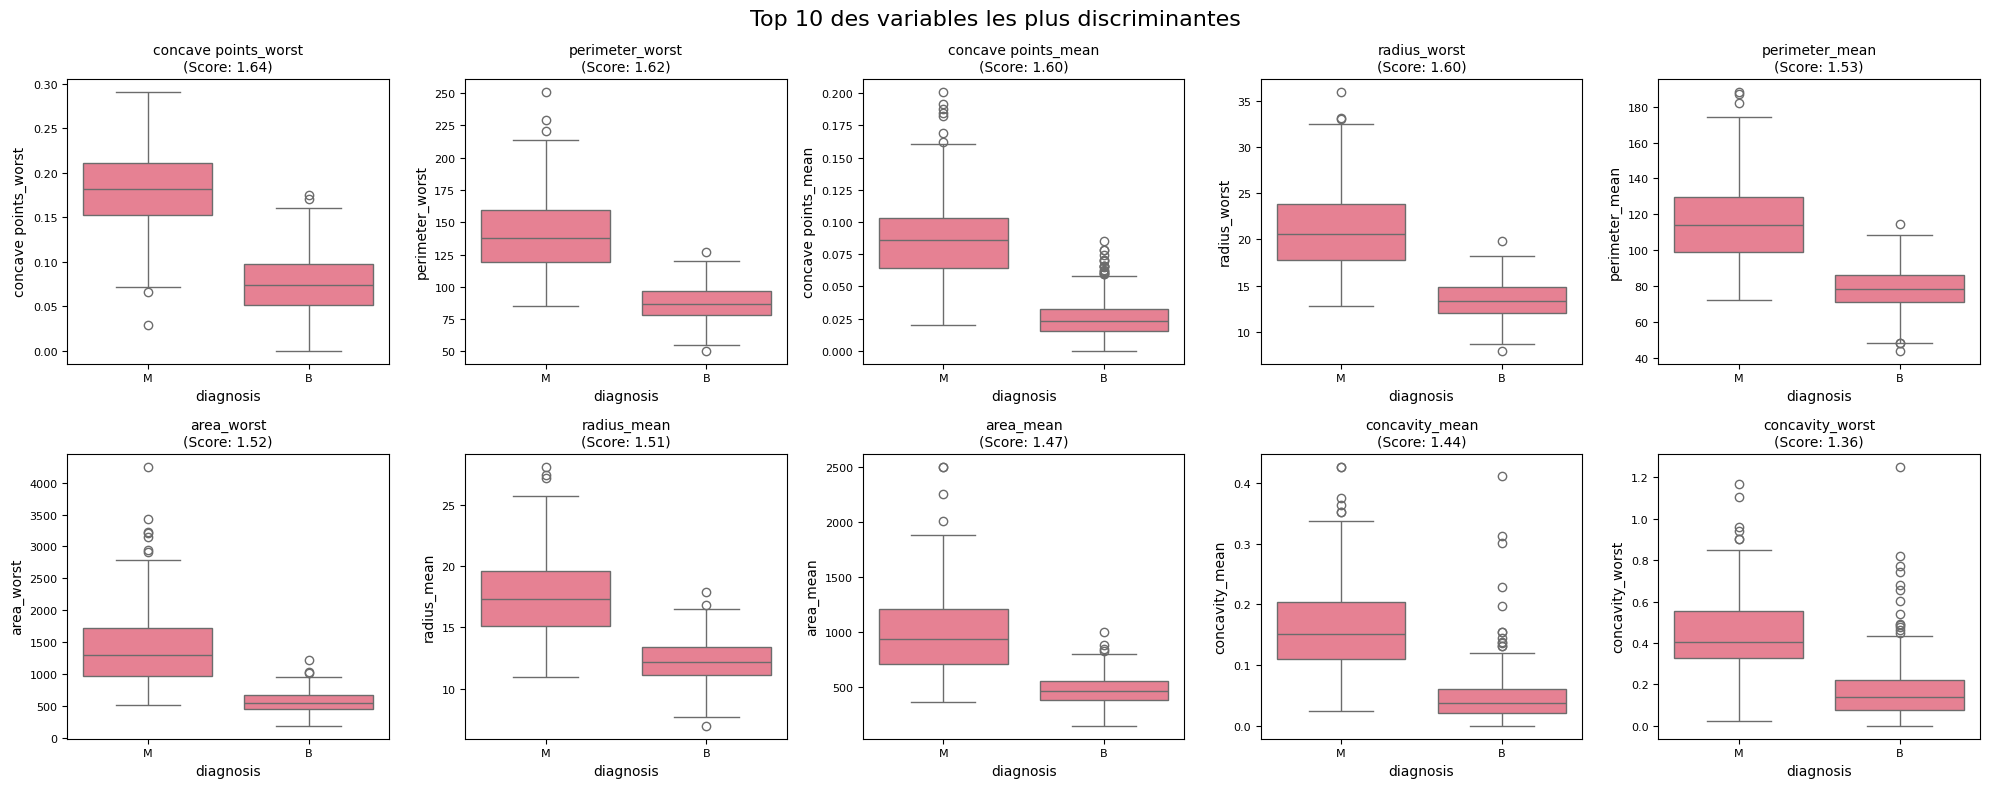

In [21]:
# Calcul des différences de moyennes entre classes (pouvoir discriminant)
y_numeric = (y == 'M').astype(int)  # Convertir en numérique

discriminant_scores = []
for col in x.columns:
    benign_mean = x[y == 'B'][col].mean()
    malignant_mean = x[y == 'M'][col].mean()
    
    # Différence normalisée par l'écart-type
    pooled_std = x[col].std()
    discriminant_score = abs(malignant_mean - benign_mean) / pooled_std
    
    discriminant_scores.append((col, discriminant_score, malignant_mean - benign_mean))

# Trier par pouvoir discriminant
discriminant_scores.sort(key=lambda x: x[1], reverse=True)

# Afficher les 15 variables les plus discriminantes
print("Top 15 des variables les plus discriminantes:")
print("Variable\t\t\t\tScore\tDifférence (M-B)")
print("-" * 60)
for var, score, diff in discriminant_scores[:15]:
    print(f"{var:30s}\t{score:.3f}\t{diff:8.3f}")

# Visualiser le top 10
top_vars = [x[0] for x in discriminant_scores[:10]]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    sns.boxplot(data=df_viz, x='diagnosis', y=var, ax=axes[i])
    axes[i].set_title(f"{var}\n(Score: {discriminant_scores[i][1]:.2f})", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

plt.suptitle('Top 10 des variables les plus discriminantes', fontsize=16)
plt.tight_layout()
plt.show()

# Export

In [12]:
out_path = "data/processed/bcw_clean.csv"
df.to_csv("../data/bcw_simple_cleaning.csv", index=False)
print("Export OK ->", out_path)

Export OK -> data/processed/bcw_clean.csv


In [24]:
# Remplacez la section "3. HYPOTHÈSES BIOLOGIQUES" par cette validation qualitative

print("3. VALIDATION DES HYPOTHÈSES BIOLOGIQUES:")
print("   H1 (TAILLE) - VALIDÉE ✓")
print("   → Boxplots montrent que les tumeurs malignes présentent systématiquement:")
print("     • Des radius, area, perimeter plus élevés")
print("     • Séparation claire entre B et M sur tous les graphiques de taille")
print("     • Médianes malignes > médianes bénignes pour toutes variables _worst")
print()

print("   H2 (IRRÉGULARITÉ) - VALIDÉE ✓") 
print("   → Visualisations révèlent que les tumeurs malignes ont:")
print("     • Concavity et compactness nettement plus élevées")
print("     • Distributions décalées vers la droite (asymétrie)")
print("     • Peu de chevauchement entre les classes B/M")
print()

print("   H3 (COMPLEXITÉ) - PARTIELLEMENT VALIDÉE ⚠️")
print("   → Analyses montrent des différences modérées:")
print("     • Symmetry : différences visibles mais avec chevauchement")
print("     • Fractal_dimension : séparation moins nette entre classes")
print("     • Variables _se généralement moins différenciatrices")

3. VALIDATION DES HYPOTHÈSES BIOLOGIQUES:
   H1 (TAILLE) - VALIDÉE ✓
   → Boxplots montrent que les tumeurs malignes présentent systématiquement:
     • Des radius, area, perimeter plus élevés
     • Séparation claire entre B et M sur tous les graphiques de taille
     • Médianes malignes > médianes bénignes pour toutes variables _worst

   H2 (IRRÉGULARITÉ) - VALIDÉE ✓
   → Visualisations révèlent que les tumeurs malignes ont:
     • Concavity et compactness nettement plus élevées
     • Distributions décalées vers la droite (asymétrie)
     • Peu de chevauchement entre les classes B/M

   H3 (COMPLEXITÉ) - PARTIELLEMENT VALIDÉE ⚠️
   → Analyses montrent des différences modérées:
     • Symmetry : différences visibles mais avec chevauchement
     • Fractal_dimension : séparation moins nette entre classes
     • Variables _se généralement moins différenciatrices
